In [10]:
# ============================================================
# Deng, Ginting, McCaskill (2019) – locally conservative flux
# reconstruction from CG1 solution, applied to the same test
# case as lcg_pinn_no_fracture.ipynb so results are comparable.
#
# Problem:  -∇·(k∇p) = f  on [0,1]²
#   k(x,y)  = 2x + 1
#   f(x,y)  = -(y² + 2x² + x)
#   p_exact = (x/2) y²
#   q_exact = -(2x+1)(y²/2, xy)
#   BC left : p = 0
#   BC right: p = y²/2
#   BC top/bottom: Neumann (k ∂p/∂n = (2x²+x) at top, 0 at bottom)
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem
from dolfinx.io import gmsh as gmshio
from dolfinx.fem import petsc
import ufl

order = 1

In [11]:
# ============================================================
# Exact solution and problem data
# ============================================================
def exact_p(points):
    pts = np.asarray(points, dtype=np.float64)
    return 0.5 * pts[:, 0] * pts[:, 1] ** 2

def exact_grad_p(points):
    """∇p = (y²/2, x·y)  [p = (x/2)y²]"""
    pts = np.asarray(points, dtype=np.float64)
    g = np.zeros((len(pts), 2), dtype=np.float64)
    g[:, 0] = 0.5 * pts[:, 1] ** 2     # ∂p/∂x = y²/2
    g[:, 1] = pts[:, 0] * pts[:, 1]    # ∂p/∂y = x·y
    return g

def exact_q(points):
    """q = -k∇p,  k = 2x+1."""
    pts = np.asarray(points, dtype=np.float64)
    k = 2.0 * pts[:, 0] + 1.0
    q = np.zeros((pts.shape[0], 2), dtype=np.float64)
    q[:, 0] = -k * 0.5 * pts[:, 1] ** 2
    q[:, 1] = -k * pts[:, 0] * pts[:, 1]
    return q

def f_callable(x):
    """f = -(y² + 2x² + x)  from -∇·((2x+1)∇p) with p = (x/2)y²."""
    return -x[1] ** 2 - 2.0 * x[0] ** 2 - x[0]

def k_callable(x):
    return (2.0 * x[0] + 1.0)[np.newaxis, :]

In [12]:
# ============================================================
# Geometry helpers (Deng et al. local problem assembly)
# ============================================================
def cell_centroid(coords):
    return np.mean(coords, axis=0)

def edge_midpoint(a, b):
    return 0.5 * (a + b)

def edge_length(a, b):
    return np.linalg.norm(b - a)

def normal_from_C_to_ti(centroid, midpoint, vi):
    """
    Unit outward normal of control-volume t_i on segment [centroid→midpoint].
    Points AWAY from vertex vi (outward from t_i, toward the centroid side).

    Convention matches Deng et al. (2019): b_τ(v, w) integrates (-κ∇v)·n_{t_i}
    where n_{t_i} is the outward normal of t_i on its internal boundary.
    """
    t = midpoint - centroid
    n1 = np.array([ t[1], -t[0]])
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    # pick the direction pointing AWAY from vi (outward from t_i)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0 else chosen

def outward_edge_normal(a, b, centroid):
    """
    Unit normal on edge [a->b] pointing outward from the triangle
    (away from centroid).
    """
    t = b - a
    n1 = np.array([ t[1], -t[0]])
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0 else chosen

REF_GRADS = np.array([[-1., -1.], [1., 0.], [0., 1.]])

In [13]:
# ============================================================
# CG1 solve  (identical to PINN notebook)
# ============================================================
def solve_cg(ref_value):
    msh, _, _ = gmshio.read_from_msh(
        f"regular_mesh_{ref_value}.msh", MPI.COMM_WORLD, 0, gdim=2
    )[0:3]

    tdim = msh.topology.dim
    fdim = tdim - 1
    h = 1.0 / (2 ** ref_value)

    V = fem.functionspace(msh, ("Lagrange", order))
    phi = ufl.TestFunction(V)
    dp  = ufl.TrialFunction(V)

    x = ufl.SpatialCoordinate(msh)
    f_m = -x[1] ** 2 - 2.0 * x[0] ** 2 - x[0]

    f_func = fem.Function(V)
    f_func.interpolate(f_callable)

    k_m = fem.Function(V, name="kappa")
    k_m.interpolate(k_callable)

    coords = msh.geometry.x
    tol = 1e-10
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()

    # Neumann tags for top / bottom
    bot_f = mesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[1], ymin, atol=tol))
    top_f = mesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[1], ymax, atol=tol))
    idx = np.concatenate([bot_f, top_f]).astype(np.int32)
    val = np.concatenate([np.full(len(bot_f), 10, np.int32), np.full(len(top_f), 20, np.int32)])
    neu_tags = mesh.meshtags(msh, fdim, idx, val)
    dsN = ufl.Measure("ds", domain=msh, subdomain_data=neu_tags)

    a = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * ufl.dx
    L = f_m * phi * ufl.dx
    L += 0.0 * phi * dsN(10)                            # bottom: g_N = 0
    L += (2.0 * x[0] ** 2 + x[0]) * phi * dsN(20)      # top:    g_N = (2x+1)x = 2x²+x

    left_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmin, atol=tol))
    right_dofs = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmax, atol=tol))
    all_dofs   = np.unique(np.concatenate([left_dofs, right_dofs]))

    dof_coords = V.tabulate_dof_coordinates()
    p_bc = fem.Function(V)
    p_bc.x.array[left_dofs]  = 0.0
    p_bc.x.array[right_dofs] = dof_coords[right_dofs, 1] ** 2 / 2.0
    bc = fem.dirichletbc(p_bc, all_dofs)

    problem = petsc.LinearProblem(
        a, L, bcs=[bc],
        petsc_options={"ksp_type": "preonly", "pc_type": "lu",
                       "pc_factor_mat_solver_type": "mumps"},
        petsc_options_prefix=f"cg_ref{ref_value}_"
    )
    p_sol = problem.solve()
    p_sol.name = "pressure"

    return {"ref": ref_value, "h": h, "omega": msh, "V": V,
            "p_sol": p_sol, "k_m": k_m, "f_func": f_func,
            "dofs": V.dofmap.index_map.size_global,
            "all_dofs": all_dofs, "left_dofs": left_dofs, "right_dofs": right_dofs,
            "dof_coords": dof_coords}

In [14]:
# ============================================================
# Deng et al. (2019) post-processing - Sec. 3
#
# This assembles the elemental system from Eq. (3.13)-(3.15):
#     A alpha = beta,
#     beta_xi = l_tau(I_tau phi_xi - phi_xi)
#              + a_tau(u_h, phi_xi)
#              + e_tau(u_h, I_tau phi_xi - phi_xi).
#
# The physical control-volume source int_{t_xi} f dx is stored
# separately and is used by the conservation diagnostic.
# ============================================================
def _tab(elem, nderiv, pts):
    """Tabulate and squeeze trailing value-size=1 dimension."""
    t = elem.tabulate(nderiv, np.atleast_2d(pts))
    return t[..., 0] if t.ndim == 4 else t   # -> (n_deriv+1, npts, Nk)

# 3-pt Gauss on [0, 1], exact through degree 5.
_T_G = np.array([0.5 - 0.5*np.sqrt(3.0/5.0), 0.5, 0.5 + 0.5*np.sqrt(3.0/5.0)])
_W_G = np.array([5.0/18.0, 4.0/9.0, 5.0/18.0])


def deng_postprocess(ctx):
    omega    = ctx["omega"]
    V        = ctx["V"]
    p_sol    = ctx["p_sol"]
    all_dofs = ctx["all_dofs"]

    def f_at(x):
        return float(-x[1]**2 - 2.0*x[0]**2 - x[0])

    def k_at(x):
        return float(2.0*x[0] + 1.0)

    # ---- basix element ----
    elem    = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    Nk      = elem.dim                      # 3 (P1) or 6 (P2)
    dof_ref = elem.points[:, :2]            # (Nk, 2) reference DOF coords

    # Locate vertex and edge-midpoint DOF indices by coordinate matching.
    def find_dof(xy):
        return int(np.argmin(np.linalg.norm(dof_ref - np.array(xy), axis=1)))
    v0 = find_dof([0.0, 0.0]); v1 = find_dof([1.0, 0.0]); v2 = find_dof([0.0, 1.0])

    edge_ref_pairs = [(v0, v1), (v1, v2), (v0, v2)]
    edge_vertex_lids = [(0, 1), (1, 2), (0, 2)]

    if order == 1:
        sub_tris          = [[v0, v1, v2]]
        tau_edge_dof_sets = [frozenset([v0, v1]), frozenset([v1, v2]), frozenset([v0, v2])]
    else:
        m01 = find_dof([0.5, 0.0]); m12 = find_dof([0.5, 0.5]); m02 = find_dof([0.0, 0.5])
        sub_tris          = [[v0, m01, m02], [v1, m01, m12], [v2, m02, m12], [m01, m12, m02]]
        tau_edge_dof_sets = [frozenset([v0, v1, m01]),
                             frozenset([v1, v2, m12]),
                             frozenset([v0, v2, m02])]

    # Volume quadrature. Degree 5 is exact for this notebook's polynomial data.
    X_iq, w_iq = basix.make_quadrature(basix.CellType.triangle, 5)
    nq_iq  = len(w_iq)
    tab_iq = _tab(elem, 1, X_iq)                              # (3, nq, Nk)
    phi_iq       = tab_iq[0]                                  # (nq, Nk)
    ref_grads_iq = np.stack([tab_iq[1], tab_iq[2]], axis=2)    # (nq, Nk, 2)

    # ---- topology ----
    tdim = omega.topology.dim
    fdim = tdim - 1
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0)]:
        omega.topology.create_connectivity(*pair)
    ctv = omega.topology.connectivity(tdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)

    geom        = omega.geometry.x[:, :2]
    num_cells   = omega.topology.index_map(tdim).size_local
    num_facets  = omega.topology.index_map(fdim).size_local
    local_cell_verts = np.array([ctv.links(c) for c in range(num_cells)])
    facet_by_vertices = {frozenset(int(v) for v in f2v.links(fi)): fi for fi in range(num_facets)}

    def tri2d_det(p0, p1, p2):
        return abs((p1[0]-p0[0])*(p2[1]-p0[1]) - (p2[0]-p0[0])*(p1[1]-p0[1]))

    def integrate_f_triangle(p0, p1, p2):
        Jsub = np.column_stack((p1 - p0, p2 - p0))
        det_sub = abs(np.linalg.det(Jsub))
        pts = p0 + X_iq @ Jsub.T
        vals = np.array([f_at(x) for x in pts])
        return det_sub * float(np.dot(vals, w_iq))

    dofmap    = V.dofmap
    dirichlet_set = set(int(d) for d in all_dofs)
    num_dofs  = dofmap.index_map.size_local
    coef_glob = {i: [] for i in range(num_dofs)}
    local_fluxes = {}

    # Cache cell geometry and CG coefficients for edge-average evaluations.
    cell_cache = []
    for ci in range(num_cells):
        verts = local_cell_verts[ci]
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        cell_cache.append({
            "verts": verts,
            "coords": coords,
            "J": J,
            "invJ": np.linalg.inv(J),
            "uvals": p_sol.x.array[dofmap.cell_dofs(ci)],
        })

    def grad_uh_in_cell(ci, x_phys):
        data = cell_cache[ci]
        xi = data["invJ"] @ (x_phys - data["coords"][0])
        t_s = _tab(elem, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        phys_g = ref_g @ data["invJ"]
        return phys_g.T @ data["uvals"]

    def averaged_kgrad_dot_n(ci, facet, x_phys, n_out):
        val = k_at(x_phys) * grad_uh_in_cell(ci, x_phys)
        adj = [int(c) for c in f2c.links(facet) if int(c) < num_cells]
        if len(adj) == 2:
            nb = adj[0] if adj[1] == ci else adj[1]
            val_nb = k_at(x_phys) * grad_uh_in_cell(nb, x_phys)
            val = 0.5 * (val + val_nb)
        return float(np.dot(val, n_out))

    for ci in range(num_cells):
        data    = cell_cache[ci]
        coords  = data["coords"]
        J       = data["J"]
        detJ    = np.linalg.det(J)
        abs_detJ = abs(detJ)
        invJ    = data["invJ"]
        uvals   = data["uvals"]
        cell_verts = data["verts"]

        # Physical DOF coordinates via affine map: x = coords[0] + dof_ref @ J.T
        dof_phys = coords[0] + dof_ref @ J.T
        cdofs = dofmap.cell_dofs(ci)

        # Physical gradients at internal quad pts: (nq, Nk, 2)
        phys_grads_iq = ref_grads_iq @ invJ
        grad_u_iq     = np.einsum("qjd,j->qd", phys_grads_iq, uvals)
        X_phys_iq     = coords[0] + X_iq @ J.T

        B          = np.zeros((Nk, Nk))
        source_t   = np.zeros(Nk)   # int_{t_xi} f dx, used for physical conservation checks
        source_phi = np.zeros(Nk)   # int_tau f phi_xi dx
        a_term     = np.zeros(Nk)   # int_tau k grad u_h . grad phi_xi dx
        e_I        = np.zeros(Nk)   # int_{partial tau cap partial t_xi} {k grad u_h}.n dx
        e_phi      = np.zeros(Nk)   # int_{partial tau} {k grad u_h}.n phi_xi dx

        # ---- Volume terms for beta ----
        for q in range(nq_iq):
            fq = f_at(X_phys_iq[q])
            kq = k_at(X_phys_iq[q])
            source_phi += abs_detJ * w_iq[q] * fq * phi_iq[q]
            a_term     += abs_detJ * w_iq[q] * kq * (phys_grads_iq[q] @ grad_u_iq[q])

        # ---- B matrix and source_t over control-volume pieces ----
        for sub_tri in sub_tris:
            sub_dr   = dof_ref[sub_tri]
            sub_dp   = dof_phys[sub_tri]
            c_ref    = np.mean(sub_dr, axis=0)
            c_phys   = np.mean(sub_dp, axis=0)

            for li, gi in enumerate(sub_tri):
                oa, ob   = sub_tri[(li+1) % 3], sub_tri[(li+2) % 3]
                midA_r   = 0.5 * (dof_ref[gi]  + dof_ref[oa])
                midB_r   = 0.5 * (dof_ref[gi]  + dof_ref[ob])
                midA_p   = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB_p   = 0.5 * (dof_phys[gi] + dof_phys[ob])

                source_t[gi] += integrate_f_triangle(dof_phys[gi], midA_p, c_phys)
                source_t[gi] += integrate_f_triangle(dof_phys[gi], c_phys, midB_p)

                nA   = normal_from_C_to_ti(c_phys, midA_p, dof_phys[gi])
                nB   = normal_from_C_to_ti(c_phys, midB_p, dof_phys[gi])
                lenA = edge_length(c_phys, midA_p)
                lenB = edge_length(c_phys, midB_p)

                for (a_r, a_p, b_r, b_p, n_s, l_s) in [
                    (c_ref, c_phys, midA_r, midA_p, nA, lenA),
                    (c_ref, c_phys, midB_r, midB_p, nB, lenB),
                ]:
                    for tg, wg in zip(_T_G, _W_G):
                        seg_r  = a_r + tg * (b_r - a_r)
                        x_p    = a_p + tg * (b_p - a_p)
                        k_g    = k_at(x_p)
                        t_s    = _tab(elem, 1, seg_r)
                        ref_g  = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
                        phys_g = ref_g @ invJ
                        B[gi, :] += wg * (-k_g * (phys_g @ n_s)) * l_s

        # ---- Edge-average term e_tau(u_h, I_tau phi_xi - phi_xi) ----
        centroid_tau = np.mean([dof_phys[v0], dof_phys[v1], dof_phys[v2]], axis=0)
        edge_normals = []
        edge_facets = []
        for (ra, rb), (la, lb) in zip(edge_ref_pairs, edge_vertex_lids):
            n_out = outward_edge_normal(dof_phys[ra], dof_phys[rb], centroid_tau)
            facet = facet_by_vertices[frozenset([int(cell_verts[la]), int(cell_verts[lb])])]
            edge_normals.append(n_out)
            edge_facets.append(facet)

        def _tau_edge_info(gi, nb):
            for es, n, facet in zip(tau_edge_dof_sets, edge_normals, edge_facets):
                if gi in es and nb in es:
                    return n, facet
            return None, None

        # e_I: I_tau phi_xi equals 1 on the external part of t_xi.
        for sub_tri in sub_tris:
            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li+1) % 3]
                ob = sub_tri[(li+2) % 3]
                for neighbor in [oa, ob]:
                    n_out, facet = _tau_edge_info(gi, neighbor)
                    if n_out is None:
                        continue
                    a_phys_e = dof_phys[gi]
                    b_phys_e = 0.5 * (dof_phys[gi] + dof_phys[neighbor])
                    seg_len  = edge_length(a_phys_e, b_phys_e)
                    for tg, wg in zip(_T_G, _W_G):
                        x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                        e_I[gi] += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * seg_len

        # e_phi: subtract phi_xi on the whole element boundary.
        for (ra, rb), n_out, facet in zip(edge_ref_pairs, edge_normals, edge_facets):
            a_ref_e = dof_ref[ra]
            b_ref_e = dof_ref[rb]
            a_phys_e = dof_phys[ra]
            b_phys_e = dof_phys[rb]
            seg_len = edge_length(a_phys_e, b_phys_e)
            for tg, wg in zip(_T_G, _W_G):
                xi_g = a_ref_e + tg * (b_ref_e - a_ref_e)
                x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                phi_edge = _tab(elem, 0, xi_g)[0, 0]
                e_phi += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * phi_edge * seg_len

        rhs = source_t - source_phi + a_term + e_I - e_phi

        # ---- Fix null space: pin one DOF to CG value ----
        fixed = {}
        for li, gd in enumerate(cdofs):
            if int(gd) in dirichlet_set:
                fixed[li] = float(p_sol.x.array[int(gd)])
                break
        if not fixed:
            fixed[0] = float(p_sol.x.array[int(cdofs[0])])

        free = [i for i in range(Nk) if i not in fixed]
        Bff  = B[np.ix_(free, free)]
        rf   = rhs[free].copy()
        for li, val in fixed.items():
            rf -= B[np.ix_(free, [li])].ravel() * val
        sol_free, *_ = np.linalg.lstsq(Bff, rf, rcond=None)

        coeffs = np.zeros(Nk)
        for s_idx, li in enumerate(free):
            coeffs[li] = sol_free[s_idx]
        for li, val in fixed.items():
            coeffs[li] = val

        for li, gd in enumerate(cdofs):
            if int(gd) < num_dofs:
                coef_glob[int(gd)].append(coeffs[li])

        # Reconstructed flux at centroid (ref centroid = (1/3, 1/3)).
        t_c     = _tab(elem, 1, np.array([1/3, 1/3]))
        ref_g_c = np.stack([t_c[1, 0], t_c[2, 0]], axis=1)
        phys_gc = ref_g_c @ invJ
        k_cent  = k_at(np.mean(coords, axis=0))
        q_rec   = -k_cent * (phys_gc.T @ coeffs)

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "q_rec": q_rec,
            "invJ": invJ,
            "cell_verts": cell_verts,
            "coords": coords,
            "rhs": rhs.copy(),              # Deng beta from Eq. (3.14)
            "source_t": source_t.copy(),    # physical int_{t_xi} f dx
            "source_phi": source_phi.copy(),
            "a_term": a_term.copy(),
            "e_term": (e_I - e_phi).copy(),
            "vertex_to_dof": {0: v0, 1: v1, 2: v2},
            "v_to_dof": {0: v0, 1: v1, 2: v2},
        }

    p_rec_arr = np.zeros(num_dofs)
    for gd, vals in coef_glob.items():
        if vals:
            p_rec_arr[gd] = np.mean(vals)

    return local_fluxes, coef_glob, p_rec_arr


In [15]:
# ============================================================
# Metric helpers – all use basix tabulation, work for any order
# ============================================================
def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0 and errors[i] > 0:
            rates.append(math.log(errors[i] / errors[i - 1]) /
                         math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def cell_detJ(omega):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    ctv  = omega.topology.connectivity(tdim, 0)
    geom = omega.geometry.x[:, :2]
    nc   = omega.topology.index_map(tdim).size_local
    dJ   = np.empty(nc)
    for c in range(nc):
        v = ctv.links(c)
        coords = geom[v]
        v1 = coords[1] - coords[0]; v2 = coords[2] - coords[0]
        dJ[c] = abs(v1[0]*v2[1] - v1[1]*v2[0])
    return dJ


def map_ref_to_phys(omega, X_ref):
    tdim = omega.topology.dim
    nc   = omega.topology.index_map(tdim).size_local
    gdim = omega.geometry.dim
    cmap = omega.geometry.cmap
    xdof = omega.geometry.dofmap
    xgeo = omega.geometry.x
    pts  = np.empty((nc, len(X_ref), gdim))
    for c in range(nc):
        pts[c] = cmap.push_forward(X_ref, xgeo[xdof[c]])[:, :gdim]
    return pts


def eval_expr_cellwise(omega, expr_ufl, X_ref, vsz):
    tdim = omega.topology.dim
    nc   = omega.topology.index_map(tdim).size_local
    expr = fem.Expression(expr_ufl, X_ref)
    vals = np.asarray(expr.eval(omega, np.arange(nc, dtype=np.int32)))
    return vals.reshape(nc, len(X_ref), vsz)


def _squeeze_tab(tab):
    """Squeeze basix 4D output (n_deriv+1, npts, Nk, 1) -> (n_deriv+1, npts, Nk)."""
    return tab[..., 0] if tab.ndim == 4 else tab


def _make_basix_grads(X_ref):
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    t     = _squeeze_tab(elem_.tabulate(1, X_ref))
    return np.stack([t[1], t[2]], axis=2)


def _make_basix_vals(X_ref):
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    t     = _squeeze_tab(elem_.tabulate(0, X_ref))
    return t[0]


def _cell_invJ_list(omega):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    ctv  = omega.topology.connectivity(tdim, 0)
    geom = omega.geometry.x[:, :2]
    nc   = omega.topology.index_map(tdim).size_local
    return [np.linalg.inv(np.column_stack(
        (geom[ctv.links(c)][1]-geom[ctv.links(c)][0],
         geom[ctv.links(c)][2]-geom[ctv.links(c)][0]))) for c in range(nc)]


_T_GAUSS = np.array([(1.0 - 1.0/np.sqrt(3))/2.0, (1.0 + 1.0/np.sqrt(3))/2.0])
_W_GAUSS = np.array([0.5, 0.5])


def _seg_flux_rec(a_phys, b_phys, n_out, coeffs, invJ, coords0, elem_):
    """Integrate (-kappa grad u)·n along segment with 2-pt Gauss."""
    seg_len = edge_length(a_phys, b_phys)
    flux = 0.0
    for tg, wg in zip(_T_GAUSS, _W_GAUSS):
        x   = a_phys + tg * (b_phys - a_phys)
        xi  = invJ @ (x - coords0)
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ invJ).T @ coeffs
        kappa   = 2.0 * x[0] + 1.0
        flux   += wg * (-kappa * np.dot(grad_uh, n_out)) * seg_len
    return flux


def boundary_vertex_mask(omega):
    tdim = omega.topology.dim
    fdim = tdim - 1
    omega.topology.create_connectivity(fdim, tdim)
    omega.topology.create_connectivity(fdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)
    nv  = omega.topology.index_map(0).size_local
    nf  = omega.topology.index_map(fdim).size_local
    is_bnd = np.zeros(nv, dtype=bool)
    for fi in range(nf):
        if len(f2c.links(fi)) == 1:
            for v in f2v.links(fi):
                if v < nv:
                    is_bnd[v] = True
    return is_bnd


def compute_p_l2(ctx, degree=5):
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    dJ  = cell_detJ(ctx["omega"])
    Xp  = map_ref_to_phys(ctx["omega"], X_ref)
    Xfl = Xp.reshape(-1, 2)
    nc  = len(dJ)
    p_ex = exact_p(Xfl).reshape(nc, -1)
    p_cg = eval_expr_cellwise(ctx["omega"], ctx["p_sol"], X_ref, 1)[:, :, 0]
    sq   = (p_cg - p_ex) ** 2
    return math.sqrt(float(ctx["omega"].comm.allreduce(
        np.sum(dJ * (sq @ w)), op=MPI.SUM)))


def compute_p_rec_l2(ctx, local_fluxes, degree=5):
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    phi_q    = _make_basix_vals(X_ref)
    omega    = ctx["omega"]
    nc       = omega.topology.index_map(omega.topology.dim).size_local
    dJ       = cell_detJ(omega)
    Xp       = map_ref_to_phys(omega, X_ref)
    err_sq   = 0.0
    for ci in range(nc):
        coeffs  = local_fluxes[ci]["coeffs"]
        p_rec_q = phi_q @ coeffs
        sq      = (p_rec_q - exact_p(Xp[ci])) ** 2
        err_sq += dJ[ci] * float(np.dot(sq, w))
    return math.sqrt(float(omega.comm.allreduce(err_sq, op=MPI.SUM)))


def compute_p_h1(ctx, degree=5):
    X_ref, w  = basix.make_quadrature(basix.CellType.triangle, degree)
    ref_gr_q  = _make_basix_grads(X_ref)
    omega     = ctx["omega"]
    tdim      = omega.topology.dim
    nc        = omega.topology.index_map(tdim).size_local
    dJ        = cell_detJ(omega)
    Xp        = map_ref_to_phys(omega, X_ref)
    invJ_list = _cell_invJ_list(omega)
    dofmap    = ctx["V"].dofmap
    err_sq    = 0.0
    for ci in range(nc):
        phys_gr_q = ref_gr_q @ invJ_list[ci]
        uvals     = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        grad_q    = np.einsum("qjd,j->qd", phys_gr_q, uvals)
        diff      = grad_q - exact_grad_p(Xp[ci])
        err_sq   += dJ[ci] * float(np.dot(np.sum(diff**2, axis=1), w))
    return math.sqrt(float(omega.comm.allreduce(err_sq, op=MPI.SUM)))


def compute_p_rec_h1(ctx, local_fluxes, degree=5):
    X_ref, w  = basix.make_quadrature(basix.CellType.triangle, degree)
    ref_gr_q  = _make_basix_grads(X_ref)
    omega     = ctx["omega"]
    tdim      = omega.topology.dim
    nc        = omega.topology.index_map(tdim).size_local
    dJ        = cell_detJ(omega)
    Xp        = map_ref_to_phys(omega, X_ref)
    invJ_list = _cell_invJ_list(omega)
    err_sq    = 0.0
    for ci in range(nc):
        phys_gr_q    = ref_gr_q @ invJ_list[ci]
        grad_tilde_q = np.einsum("qjd,j->qd", phys_gr_q, local_fluxes[ci]["coeffs"])
        diff         = grad_tilde_q - exact_grad_p(Xp[ci])
        err_sq      += dJ[ci] * float(np.dot(np.sum(diff**2, axis=1), w))
    return math.sqrt(float(omega.comm.allreduce(err_sq, op=MPI.SUM)))


def compute_p_h1_energy(ctx, degree=5):
    X_ref, w  = basix.make_quadrature(basix.CellType.triangle, degree)
    ref_gr_q  = _make_basix_grads(X_ref)
    omega     = ctx["omega"]
    tdim      = omega.topology.dim
    nc        = omega.topology.index_map(tdim).size_local
    dJ        = cell_detJ(omega)
    Xp        = map_ref_to_phys(omega, X_ref)
    invJ_list = _cell_invJ_list(omega)
    dofmap    = ctx["V"].dofmap
    err_sq    = 0.0
    for ci in range(nc):
        phys_gr_q = ref_gr_q @ invJ_list[ci]
        uvals     = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        grad_q    = np.einsum("qjd,j->qd", phys_gr_q, uvals)
        diff      = grad_q - exact_grad_p(Xp[ci])
        k_qp      = 2.0 * Xp[ci, :, 0] + 1.0
        err_sq   += dJ[ci] * float(np.dot(np.sum(diff**2, axis=1) * k_qp, w))
    return math.sqrt(float(omega.comm.allreduce(err_sq, op=MPI.SUM)))


def compute_p_rec_h1_energy(ctx, local_fluxes, degree=5):
    X_ref, w  = basix.make_quadrature(basix.CellType.triangle, degree)
    ref_gr_q  = _make_basix_grads(X_ref)
    omega     = ctx["omega"]
    tdim      = omega.topology.dim
    nc        = omega.topology.index_map(tdim).size_local
    dJ        = cell_detJ(omega)
    Xp        = map_ref_to_phys(omega, X_ref)
    invJ_list = _cell_invJ_list(omega)
    err_sq    = 0.0
    for ci in range(nc):
        phys_gr_q    = ref_gr_q @ invJ_list[ci]
        grad_tilde_q = np.einsum("qjd,j->qd", phys_gr_q, local_fluxes[ci]["coeffs"])
        diff         = grad_tilde_q - exact_grad_p(Xp[ci])
        k_qp         = 2.0 * Xp[ci, :, 0] + 1.0
        err_sq      += dJ[ci] * float(np.dot(np.sum(diff**2, axis=1) * k_qp, w))
    return math.sqrt(float(omega.comm.allreduce(err_sq, op=MPI.SUM)))


def compute_q_l2(ctx, q_cell_vals, degree=5):
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    dJ  = cell_detJ(ctx["omega"])
    Xp  = map_ref_to_phys(ctx["omega"], X_ref)
    Xfl = Xp.reshape(-1, 2)
    nc  = len(dJ)
    q_ex = exact_q(Xfl).reshape(nc, len(X_ref), 2)
    sq   = np.sum((q_cell_vals - q_ex) ** 2, axis=2)
    return math.sqrt(float(ctx["omega"].comm.allreduce(
        np.sum(dJ * (sq @ w)), op=MPI.SUM)))


def get_q_cg_cell(ctx, X_ref):
    q_ufl = -ctx["k_m"] * ufl.grad(ctx["p_sol"])
    return eval_expr_cellwise(ctx["omega"], q_ufl, X_ref, 2)


def get_q_rec_cell(ctx, local_fluxes, X_ref):
    ref_gr_q = _make_basix_grads(X_ref)
    omega    = ctx["omega"]
    tdim     = omega.topology.dim
    nc       = omega.topology.index_map(tdim).size_local
    nq       = len(X_ref)
    q_out    = np.zeros((nc, nq, 2))
    omega.topology.create_connectivity(tdim, 0)
    ctv  = omega.topology.connectivity(tdim, 0)
    geom = omega.geometry.x[:, :2]
    for ci, data in local_fluxes.items():
        if ci >= nc:
            continue
        coeffs    = data["coeffs"]
        invJ      = data["invJ"]
        coords    = geom[ctv.links(ci)]
        J         = np.column_stack((coords[1]-coords[0], coords[2]-coords[0]))
        X_phys_q  = coords[0] + X_ref @ J.T
        k_q       = 2.0 * X_phys_q[:, 0] + 1.0
        phys_gr_q = ref_gr_q @ invJ
        grad_q    = np.einsum("qjd,j->qd", phys_gr_q, coeffs)
        q_out[ci] = -(k_q[:, None] * grad_q)
    return q_out


def compute_lce_per_element(ctx, local_fluxes, use_rec=True):
    """Whole-element residual, kept as a diagnostic rather than a Deng guarantee."""
    omega  = ctx["omega"]
    tdim   = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    ctv    = omega.topology.connectivity(tdim, 0)
    geom   = omega.geometry.x[:, :2]
    nc     = omega.topology.index_map(tdim).size_local
    elem_  = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    dofmap = ctx["V"].dofmap

    lce = np.zeros(nc)
    for ci in range(nc):
        cell_verts = ctv.links(ci)
        coords     = geom[cell_verts]
        centroid   = np.mean(coords, axis=0)
        invJ       = np.linalg.inv(np.column_stack((coords[1]-coords[0], coords[2]-coords[0])))
        source     = float(np.sum(local_fluxes[ci]["source_t"]))

        if use_rec:
            coeffs = local_fluxes[ci]["coeffs"]
            invJ_c = local_fluxes[ci]["invJ"]
            coords0 = local_fluxes[ci]["coords"][0]
        else:
            coeffs = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
            invJ_c = invJ
            coords0 = coords[0]

        flux = 0.0
        for e in range(3):
            a = coords[e]
            b = coords[(e+1) % 3]
            n_e = outward_edge_normal(a, b, centroid)
            flux += _seg_flux_rec(a, b, n_e, coeffs, invJ_c, coords0, elem_)

        lce[ci] = flux - source
    return lce


# ------------------------------------------------------------------
# Local Conservation Error per control volume (nodal dual cell)
#
# CV geometry (Deng 2019 Fig. 4 / 5):
#   order=1: element centroid + element edge midpoints (pA=midA, pB=midB)
#   order=2: sub-tri centroid (vi+midA+midB)/3 + sub-edge midpoints
#
# The residual uses the physical source int_{t_xi} f dx stored by
# deng_postprocess, not the algebraic beta from A alpha = beta.
# ------------------------------------------------------------------
def compute_lce_per_cv(ctx, local_fluxes, use_rec=True):
    omega  = ctx["omega"]
    tdim   = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    omega.topology.create_connectivity(0, tdim)
    ctv    = omega.topology.connectivity(tdim, 0)
    vtc    = omega.topology.connectivity(0, tdim)
    geom   = omega.geometry.x[:, :2]
    nc     = omega.topology.index_map(tdim).size_local
    nv     = omega.topology.index_map(0).size_local

    local_cell_verts = np.array([ctv.links(c) for c in range(nc)])
    elem_  = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    dofmap = ctx["V"].dofmap

    lce_cv = np.zeros(nv)
    for vid in range(nv):
        adj_cells = list(vtc.links(vid))
        flux_sum = 0.0
        src_sum = 0.0
        for ci in adj_cells:
            if ci >= nc:
                continue
            verts    = local_cell_verts[ci]
            coords   = geom[verts]
            li       = int(np.where(verts == vid)[0][0])
            vi       = coords[li]
            midA = 0.5 * (coords[li] + coords[(li+1) % 3])
            midB = 0.5 * (coords[li] + coords[(li-1) % 3])

            if order == 1:
                c_seg = np.mean(coords, axis=0)
                pA, pB = midA, midB
            else:
                c_seg = (vi + midA + midB) / 3.0
                pA    = 0.5 * (vi + midA)
                pB    = 0.5 * (vi + midB)

            if use_rec:
                coeffs_c = local_fluxes[ci]["coeffs"]
                invJ_c   = local_fluxes[ci]["invJ"]
                coords0  = local_fluxes[ci]["coords"][0]
            else:
                coeffs_c = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
                invJ_c   = np.linalg.inv(np.column_stack(
                    (coords[1]-coords[0], coords[2]-coords[0])))
                coords0  = coords[0]

            for seg_a, seg_b in [(c_seg, pA), (c_seg, pB)]:
                n_seg = normal_from_C_to_ti(seg_a, seg_b, vi)
                flux_sum += _seg_flux_rec(seg_a, seg_b, n_seg,
                                          coeffs_c, invJ_c, coords0, elem_)

            gi_dof = local_fluxes[ci].get("vertex_to_dof", local_fluxes[ci]["v_to_dof"])[li]
            src_sum += local_fluxes[ci]["source_t"][gi_dof]

        lce_cv[vid] = flux_sum - src_sum
    return lce_cv


In [16]:
# ============================================================
# Single-reference run (ref=REF_DEMO) — quick sanity check
# ============================================================
REF_DEMO = 6  # match lcg_pinn_no_fracture.ipynb: ref=6, h=1/64
degree_quad = 5

t0 = time.perf_counter()
ctx_demo = solve_cg(REF_DEMO)
t_cg = time.perf_counter() - t0

t1 = time.perf_counter()
lf_demo, coef_demo, p_rec_demo = deng_postprocess(ctx_demo)
t_post = time.perf_counter() - t1
t_total = t_cg + t_post

X_ref_q, _ = basix.make_quadrature(basix.CellType.triangle, degree_quad)

q_cg_cell  = get_q_cg_cell(ctx_demo, X_ref_q)
q_rec_cell = get_q_rec_cell(ctx_demo, lf_demo, X_ref_q)

err_p      = compute_p_l2(ctx_demo, degree=degree_quad)
err_pREC   = compute_p_rec_l2(ctx_demo, lf_demo, degree=degree_quad)
h1_p       = compute_p_h1(ctx_demo, degree=degree_quad)
h1_pREC    = compute_p_rec_h1(ctx_demo, lf_demo, degree=degree_quad)
ek_p       = compute_p_h1_energy(ctx_demo, degree=degree_quad)
ek_pREC    = compute_p_rec_h1_energy(ctx_demo, lf_demo, degree=degree_quad)
err_qCG    = compute_q_l2(ctx_demo, q_cg_cell,  degree=degree_quad)
err_qR     = compute_q_l2(ctx_demo, q_rec_cell, degree=degree_quad)

lce_elem_cg  = compute_lce_per_element(ctx_demo, lf_demo, use_rec=False)
lce_elem_rec = compute_lce_per_element(ctx_demo, lf_demo, use_rec=True)
lce_cv_rec   = compute_lce_per_cv(ctx_demo, lf_demo, use_rec=True)
lce_cv_cg    = compute_lce_per_cv(ctx_demo, lf_demo, use_rec=False)

is_bnd_demo  = boundary_vertex_mask(ctx_demo["omega"])
interior_ids = np.where(~is_bnd_demo)[0]
lce_cv_rec_int = lce_cv_rec[interior_ids]
lce_cv_cg_int  = lce_cv_cg[interior_ids]

print("=" * 70)
print(f"  Deng et al. (2019) — ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
print("=" * 70)
print(f"  DOFs                                  = {ctx_demo['dofs']}")
print(f"  CG solve time                         = {t_cg:.4f} s")
print(f"  Post-processing time                  = {t_post:.4f} s")
print(f"  Total Deng time                       = {t_total:.4f} s")
print(f"  ||p_CG  - p||_L2                      = {err_p:.6e}")
print(f"  ||p_rec - p||_L2                      = {err_pREC:.6e}")
print(f"  |p_CG  - p|_H1 (std semi-norm)        = {h1_p:.6e}")
print(f"  |p_rec - p|_H1 (std semi-norm)        = {h1_pREC:.6e}")
print(f"  |p_CG  - p|_H1k (energy semi-norm)    = {ek_p:.6e}")
print(f"  |p_rec - p|_H1k (energy semi-norm)    = {ek_pREC:.6e}")
print(f"  ||v_h - v||_L2                        = {err_qCG:.6e}")
print(f"  ||vtilde_h - v||_L2                   = {err_qR:.6e}")
print(f"  v_h / vtilde_h error ratio            = {err_qCG / err_qR:.4f}")
print()
print(f"  --- Whole-element residual R_tau diagnostic ---")
print(f"  max  |R_tau(v_h)|                    = {np.max(np.abs(lce_elem_cg)):.6e}   (diagnostic)")
print(f"  max  |R_tau(vtilde_h)|               = {np.max(np.abs(lce_elem_rec)):.6e}   (diagnostic)")
print(f"  mean |R_tau(v_h)|                   = {np.mean(np.abs(lce_elem_cg)):.6e}")
print(f"  mean |R_tau(vtilde_h)|              = {np.mean(np.abs(lce_elem_rec)):.6e}")
print()
print(f"  --- Interior CV residual R_xi (vertex dual cells, Lemma 3.3) ---")
print(f"  max  |R_xi(v_h)| int                 = {np.max(np.abs(lce_cv_cg_int)):.6e}   (not conservative)")
print(f"  max  |R_xi(vtilde_h)| int            = {np.max(np.abs(lce_cv_rec_int)):.6e}   (discrete conservation: exact)")
print(f"  mean |R_xi(v_h)| int                = {np.mean(np.abs(lce_cv_cg_int)):.6e}")
print(f"  mean |R_xi(vtilde_h)| int           = {np.mean(np.abs(lce_cv_rec_int)):.6e}")
print("=" * 70)
print()
print("  Deng Lemma 3.3 guarantees exact physical conservation on interior nodal CVs.")
print("  Whole-element residuals are retained only as a diagnostic.")
print("  CG has no such guarantee — it is not locally conservative.")


Info    : Reading 'regular_mesh_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_6.msh'
  Deng et al. (2019) — ref=6, h=1.5625e-02
  DOFs                                  = 4225
  CG solve time                         = 5.5982 s
  Post-processing time                  = 23.4126 s
  Total Deng time                       = 29.0107 s
  ||p_CG  - p||_L2                      = 3.030237e-05
  ||p_rec - p||_L2                      = 3.003905e-05
  |p_CG  - p|_H1 (std semi-norm)        = 6.639402e-03
  |p_rec - p|_H1 (std semi-norm)        = 6.639241e-03
  |p_CG  - p|_H1k (energy semi-norm)    = 9.743397e-03
  |p_rec - p|_H1k (energy semi-norm)    = 9.743238e-03
  ||v_h - v||_L2                        = 1.478365e-02
  ||vtilde_h - v||_L2                   = 1.478349e-02
  v_h / vtilde_h error ratio            = 1.0000

  --- Whole-element residual R_tau diagnostic ---
  max  |R_tau(v_h)|                    = 3.643419e-04   (d

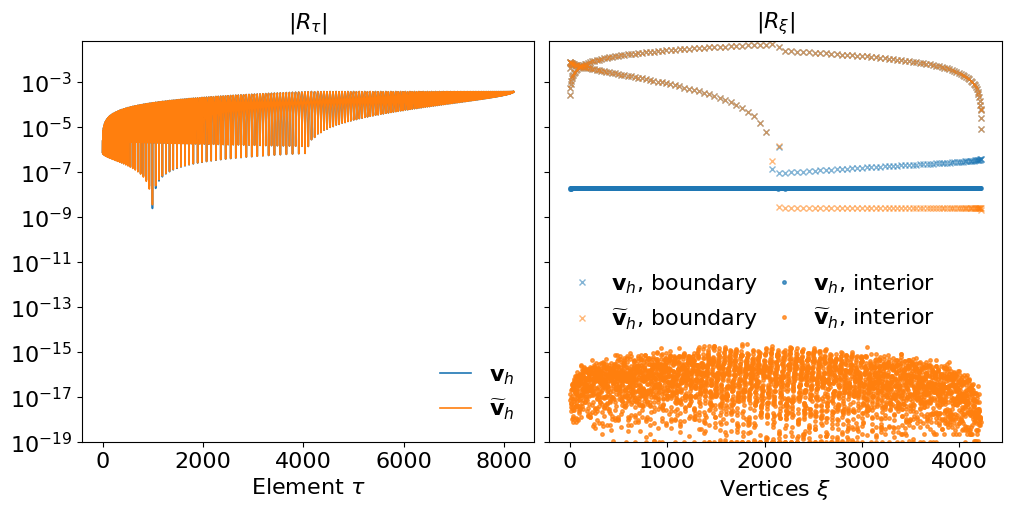

Boundary CVs: 256 / 4225
Interior CVs: 3969 / 4225
R_tau / R_xi residual summary
set            max v_h  max vtilde    mean v_h mean vtilde
R_tau       3.6434e-04  3.6435e-04  1.4241e-04  1.4242e-04
R_xi bnd    4.5664e-02  4.5663e-02  7.1623e-03  7.1617e-03
R_xi int    1.8241e-08  2.3115e-15  1.8208e-08  1.2897e-16


In [29]:
# ============================================================
# R_tau / R_xi plots (element-level and control-volume level)
# Uses variables computed in cell-06: lce_elem_cg, lce_elem_rec,
# lce_cv_cg, lce_cv_rec, is_bnd_demo, interior_ids
# ============================================================

res_roundoff_floor = 1e-19
res_plot_floor = res_roundoff_floor

def _res_plot(vals):
    return np.maximum(np.abs(vals), res_plot_floor)

def _res_stats(vals):
    vals = np.abs(vals)
    return np.max(vals), np.mean(vals)

boundary_ids = np.where(is_bnd_demo)[0]
lce_cv_cg_bnd  = lce_cv_cg[boundary_ids]
lce_cv_rec_bnd = lce_cv_rec[boundary_ids]

plot_font = 16
legend_font = 16
res_ymax_buffer = 1.35
elem_legend_loc = "lower right"
cv_legend_loc = "center"
cv_legend_bbox = None  # e.g. (0.55, 0.45) if you want manual placement
cv_legend_bbox = (0.45, 0.35)  # example manual placement to avoid overlap with points
res_ylim_values = np.abs(np.concatenate([
    lce_elem_cg, lce_elem_rec,
    lce_cv_cg_bnd, lce_cv_rec_bnd,
    lce_cv_cg_int, lce_cv_rec_int,
]))
res_ylim_values = res_ylim_values[np.isfinite(res_ylim_values) & (res_ylim_values > 0.0)]
res_ymin = res_roundoff_floor
res_ymax = (res_ylim_values.max() if res_ylim_values.size else 1.0) * res_ymax_buffer
if res_ymax <= res_ymin:
    res_ymax = 1.2 * res_ymin

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, constrained_layout=True)

ax = axes[0]
ax.semilogy(_res_plot(lce_elem_cg), "-", lw=1.2, color="C0", label=r"$\mathbf{v}_h$")
ax.semilogy(_res_plot(lce_elem_rec), "-", lw=1.2, color="C1", label=r"$\widetilde{\mathbf{v}}_h$")
ax.set_title(r"$|R_\tau|$", fontsize=plot_font, pad=10)
ax.set_xlabel(r"Element $\tau$", fontsize=plot_font)
# ax.set_ylabel(r"Residual magnitude", fontsize=plot_font)
# ax.grid(True, which="both", alpha=0.20)
ax.grid(False)
ax.set_ylim(res_ymin, res_ymax)
ax.tick_params(axis="both", which="both", labelsize=plot_font)
ax.legend(
    frameon=True, facecolor="white", edgecolor="none", framealpha=0.88,
    fontsize=legend_font, ncol=1, handlelength=1.4, loc=elem_legend_loc,
)

ax = axes[1]
cv_ids = np.arange(len(lce_cv_cg))
ax.semilogy(boundary_ids, _res_plot(lce_cv_cg_bnd), "x", ms=5.0, color="C0", alpha=0.55, mew=1.0,
            label=r"$\mathbf{v}_h$, boundary")
ax.semilogy(boundary_ids, _res_plot(lce_cv_rec_bnd), "x", ms=5.0, color="C1", alpha=0.55, mew=1.0,
            label=r"$\widetilde{\mathbf{v}}_h$, boundary")
ax.semilogy(interior_ids, _res_plot(lce_cv_cg_int), ".", ms=5.0, color="C0", alpha=0.75,
            label=r"$\mathbf{v}_h$, interior")
ax.semilogy(interior_ids, _res_plot(lce_cv_rec_int), ".", ms=5.0, color="C1", alpha=0.75,
            label=r"$\widetilde{\mathbf{v}}_h$, interior")
ax.set_title(r"$|R_\xi|$", fontsize=plot_font, pad=10)
ax.set_xlabel(r"Vertices $\xi$", fontsize=plot_font)
ax.set_ylabel("")
# ax.grid(True, which="both", alpha=0.20)
ax.grid(False)
ax.set_ylim(res_ymin, res_ymax)
ax.tick_params(axis="both", which="both", labelsize=plot_font)
ax.tick_params(axis="y", which="both", labelleft=False)
cv_legend_kwargs = {"loc": cv_legend_loc}
if cv_legend_bbox is not None:
    cv_legend_kwargs["bbox_to_anchor"] = cv_legend_bbox
ax.legend(
    frameon=False, facecolor="white", edgecolor="none", framealpha=0.88,
    fontsize=legend_font, ncol=2, columnspacing=0.7, handlelength=1.0,
    **cv_legend_kwargs,
)

plt.show()

print(f"Boundary CVs: {len(boundary_ids)} / {len(lce_cv_rec)}")
print(f"Interior CVs: {len(interior_ids)} / {len(lce_cv_rec)}")
print(r"R_tau / R_xi residual summary")
print(f"{'set':<10} {'max v_h':>11} {'max vtilde':>11} {'mean v_h':>11} {'mean vtilde':>11}")
for name, vals_cg, vals_rec in [
    ("R_tau", lce_elem_cg, lce_elem_rec),
    ("R_xi bnd", lce_cv_cg_bnd, lce_cv_rec_bnd),
    ("R_xi int", lce_cv_cg_int, lce_cv_rec_int),
]:
    max_cg, mean_cg = _res_stats(vals_cg)
    max_rec, mean_rec = _res_stats(vals_rec)
    print(f"{name:<10} {max_cg:11.4e} {max_rec:11.4e} {mean_cg:11.4e} {mean_rec:11.4e}")


In [9]:
# ============================================================
# Convergence study: ref = 2, 3, 4, 5, 6
# ============================================================
CONV_REFS = [2, 3, 4, 5, 6]
results   = []

X_ref_q, _ = basix.make_quadrature(basix.CellType.triangle, degree_quad)

for ref in CONV_REFS:
    print(f"ref={ref} ...", end=" ", flush=True)
    t0  = time.perf_counter()
    ctx = solve_cg(ref)
    t_cg_r = time.perf_counter() - t0

    t1  = time.perf_counter()
    lf, coef, p_rec_arr = deng_postprocess(ctx)
    t_post_r = time.perf_counter() - t1

    qCG  = get_q_cg_cell(ctx, X_ref_q)
    qREC = get_q_rec_cell(ctx, lf, X_ref_q)

    ep       = compute_p_l2(ctx, degree=degree_quad)
    epREC    = compute_p_rec_l2(ctx, lf, degree=degree_quad)
    eh1_p    = compute_p_h1(ctx, degree=degree_quad)
    eh1_pR   = compute_p_rec_h1(ctx, lf, degree=degree_quad)
    ek_p     = compute_p_h1_energy(ctx, degree=degree_quad)
    ek_pR    = compute_p_rec_h1_energy(ctx, lf, degree=degree_quad)
    eqCG     = compute_q_l2(ctx, qCG,  degree=degree_quad)
    eqREC    = compute_q_l2(ctx, qREC, degree=degree_quad)

    lce_cg_e  = compute_lce_per_element(ctx, lf, use_rec=False)
    lce_rec_e = compute_lce_per_element(ctx, lf, use_rec=True)
    lce_cv_rec = compute_lce_per_cv(ctx, lf, use_rec=True)
    lce_cv_cg  = compute_lce_per_cv(ctx, lf, use_rec=False)

    # Split CV residuals into interior vs boundary
    is_bnd = boundary_vertex_mask(ctx["omega"])
    int_ids = np.where(~is_bnd)[0]
    lce_cv_rec_int = lce_cv_rec[int_ids]
    lce_cv_cg_int  = lce_cv_cg[int_ids]

    results.append({
        "ref":        ref,
        "h":          ctx["h"],
        "dofs":       ctx["dofs"],
        "p_L2":       ep,
        "pREC_L2":    epREC,
        "p_H1":       eh1_p,
        "pREC_H1":    eh1_pR,
        "p_H1k":      ek_p,
        "pREC_H1k":   ek_pR,
        "qCG_L2":     eqCG,
        "qREC_L2":    eqREC,
        # Whole-element residual diagnostic
        "max_Ri_CG":  float(np.max(np.abs(lce_cg_e))),
        "mean_Ri_CG": float(np.mean(np.abs(lce_cg_e))),
        "max_Ri_rec":  float(np.max(np.abs(lce_rec_e))),
        "mean_Ri_rec": float(np.mean(np.abs(lce_rec_e))),
        # CV-level residual — all vertices
        "max_Ri_cv_rec":  float(np.max(np.abs(lce_cv_rec))),
        "mean_Ri_cv_rec": float(np.mean(np.abs(lce_cv_rec))),
        # CV-level residual — interior vertices only (Deng guarantee zone)
        "max_Ri_cv_int_cg":  float(np.max(np.abs(lce_cv_cg_int))),
        "max_Ri_cv_int_rec": float(np.max(np.abs(lce_cv_rec_int))),
        "t_cg":    t_cg_r,
        "t_post":  t_post_r,
        "t_total": t_cg_r + t_post_r,
    })
    print(f"done  p_L2={ep:.2e}  |p_CG|_H1k={ek_p:.2e}  |p_rec|_H1k={ek_pR:.2e}  "
          f"vtilde_L2={eqREC:.2e}  R_xi_int={np.max(np.abs(lce_cv_rec_int)):.2e}  "
          f"T_total={t_cg_r + t_post_r:.2f}s")

ref=2 ... Info    : Reading 'regular_mesh_2.msh'...
Info    : 153 entities
Info    : 25 nodes
Info    : 153 elements
Info    : Done reading 'regular_mesh_2.msh'
done  p_L2=7.55e-03  |p_CG|_H1k=1.54e-01  |p_rec|_H1k=1.54e-01  vtilde_L2=2.32e-01  R_xi_int=4.16e-16  T_total=0.48s
ref=3 ... Info    : Reading 'regular_mesh_3.msh'...
Info    : 593 entities
Info    : 81 nodes
Info    : 593 elements
Info    : Done reading 'regular_mesh_3.msh'
done  p_L2=1.93e-03  |p_CG|_H1k=7.77e-02  |p_rec|_H1k=7.76e-02  vtilde_L2=1.18e-01  R_xi_int=1.18e-15  T_total=0.63s
ref=4 ... Info    : Reading 'regular_mesh_4.msh'...
Info    : 2337 entities
Info    : 289 nodes
Info    : 2337 elements
Info    : Done reading 'regular_mesh_4.msh'
done  p_L2=4.84e-04  |p_CG|_H1k=3.89e-02  |p_rec|_H1k=3.89e-02  vtilde_L2=5.90e-02  R_xi_int=1.41e-15  T_total=1.58s
ref=5 ... Info    : Reading 'regular_mesh_5.msh'...
Info    : 9281 entities
Info    : 1089 nodes
Info    : 9281 elements
Info    : Done reading 'regular_mesh_5.msh

In [10]:
# ============================================================
# Summary tables
# ============================================================
hs        = [r["h"]        for r in results]
p_errs    = [r["p_L2"]     for r in results]
pREC_errs = [r["pREC_L2"]  for r in results]
p_H1s     = [r["p_H1"]     for r in results]
pR_H1s    = [r["pREC_H1"]  for r in results]
p_H1ks    = [r["p_H1k"]    for r in results]
pR_H1ks   = [r["pREC_H1k"] for r in results]
qCG_errs  = [r["qCG_L2"]   for r in results]
qR_errs   = [r["qREC_L2"]  for r in results]

rp     = convergence_rate(p_errs,    hs)
rpR    = convergence_rate(pREC_errs, hs)
rpH1   = convergence_rate(p_H1s,     hs)
rpRH1  = convergence_rate(pR_H1s,    hs)
rpH1k  = convergence_rate(p_H1ks,    hs)
rpRH1k = convergence_rate(pR_H1ks,   hs)
rqC    = convergence_rate(qCG_errs,  hs)
rqR    = convergence_rate(qR_errs,   hs)

def fmt_rate(x): return "---" if x is None else f"{x:.3f}"

# --- Table 1: L2 norms ---
print("=== L2 norms ===")
hdr = (f"{'ref':>4} {'h':>10} {'DOFs':>7}  "
       f"{'||p_h-p||':>14} {'rt':>6}  "
       f"{'||ptilde-p||':>14} {'rt':>6}  "
       f"{'||v_h-v||':>14} {'rt':>6}  "
       f"{'||vtilde-v||':>14} {'rt':>6}")
print(hdr)
print("-" * len(hdr))
for i, r in enumerate(results):
    print(f"{r['ref']:4d} {r['h']:10.4e} {r['dofs']:7d}  "
          f"{r['p_L2']:14.4e} {fmt_rate(rp[i]):>6}  "
          f"{r['pREC_L2']:14.4e} {fmt_rate(rpR[i]):>6}  "
          f"{r['qCG_L2']:14.4e} {fmt_rate(rqC[i]):>6}  "
          f"{r['qREC_L2']:14.4e} {fmt_rate(rqR[i]):>6}")

# --- Table 2: H1 semi-norms ---
print()
print("=== H1 semi-norms ===")
hdr2 = (f"{'ref':>4} {'h':>10} {'DOFs':>7}  "
        f"{'|p_h|_H1':>13} {'rt':>6}  "
        f"{'|ptilde|_H1':>13} {'rt':>6}  "
        f"{'|p_h|_H1k':>13} {'rt':>6}  "
        f"{'|ptilde|_H1k':>13} {'rt':>6}")
print(hdr2)
print("-" * len(hdr2))
for i, r in enumerate(results):
    print(f"{r['ref']:4d} {r['h']:10.4e} {r['dofs']:7d}  "
          f"{r['p_H1']:13.4e} {fmt_rate(rpH1[i]):>6}  "
          f"{r['pREC_H1']:13.4e} {fmt_rate(rpRH1[i]):>6}  "
          f"{r['p_H1k']:13.4e} {fmt_rate(rpH1k[i]):>6}  "
          f"{r['pREC_H1k']:13.4e} {fmt_rate(rpRH1k[i]):>6}")

# --- Table 3: residual diagnostics ---
# Whole-element residuals are diagnostics.
# CV-level residuals use the physical int_C f source; Deng should be near machine precision on interior nodal CVs.
ri_CG   = [r["max_Ri_CG"]          for r in results]
ri_rec  = [r["max_Ri_rec"]         for r in results]
ri_cv_cg= [r["max_Ri_cv_int_cg"]   for r in results]
ri_cv_r = [r["max_Ri_cv_int_rec"]  for r in results]
r_ri_CG  = convergence_rate(ri_CG,  hs)
r_ri_rec = convergence_rate(ri_rec, hs)
r_cv_cg  = convergence_rate(ri_cv_cg, hs)
r_cv_rec = convergence_rate(ri_cv_r,  hs)

print()
print("=== R_tau / R_xi residual diagnostics ===")
hdr3 = (f"{'ref':>4} {'h':>10}  "
        f"{'max|R_tau(v_h)|':>18} {'rt':>6}  "
        f"{'max|R_tau(vtilde)|':>20} {'rt':>6}  "
        f"{'max|R_xi(v_h)| int':>20} {'rt':>6}  "
        f"{'max|R_xi(vtilde)| int':>23} {'rt':>6}")
print(hdr3)
print("-" * len(hdr3))
for i, r in enumerate(results):
    print(f"{r['ref']:4d} {r['h']:10.4e}  "
          f"{r['max_Ri_CG']:17.4e} {fmt_rate(r_ri_CG[i]):>6}  "
          f"{r['max_Ri_rec']:18.4e} {fmt_rate(r_ri_rec[i]):>6}  "
          f"{r['max_Ri_cv_int_cg']:18.4e} {fmt_rate(r_cv_cg[i]):>6}  "
          f"{r['max_Ri_cv_int_rec']:20.4e} {fmt_rate(r_cv_rec[i]):>6}")

# --- Table 4: computation times ---
print()
print("=== Computation times ===")
hdr4 = (f"{'ref':>4} {'h':>10} {'DOFs':>7}  "
        f"{'CG solve [s]':>13} {'Deng post [s]':>15} {'total [s]':>11}")
print(hdr4)
print("-" * len(hdr4))
for r in results:
    print(f"{r['ref']:4d} {r['h']:10.4e} {r['dofs']:7d}  "
          f"{r['t_cg']:13.4f} {r['t_post']:15.4f} {r['t_total']:11.4f}")

=== L2 norms ===
 ref          h    DOFs       ||p_h-p||     rt    ||ptilde-p||     rt       ||v_h-v||     rt    ||vtilde-v||     rt
-------------------------------------------------------------------------------------------------------------------
   2 2.5000e-01      25      7.5452e-03    ---      6.8507e-03    ---      2.3178e-01    ---      2.3153e-01    ---
   3 1.2500e-01      81      1.9253e-03  1.970      1.8093e-03  1.921      1.1762e-01  0.979      1.1756e-01  0.978
   4 6.2500e-02     289      4.8398e-04  1.992      4.6804e-04  1.951      5.9055e-02  0.994      5.9046e-02  0.993
   5 3.1250e-02    1089      1.2117e-04  1.998      1.1910e-04  1.975      2.9559e-02  0.998      2.9558e-02  0.998
   6 1.5625e-02    4225      3.0302e-05  1.999      3.0039e-05  1.987      1.4784e-02  1.000      1.4783e-02  1.000

=== H1 semi-norms ===
 ref          h    DOFs       |p_h|_H1     rt    |ptilde|_H1     rt      |p_h|_H1k     rt   |ptilde|_H1k     rt
------------------------------------

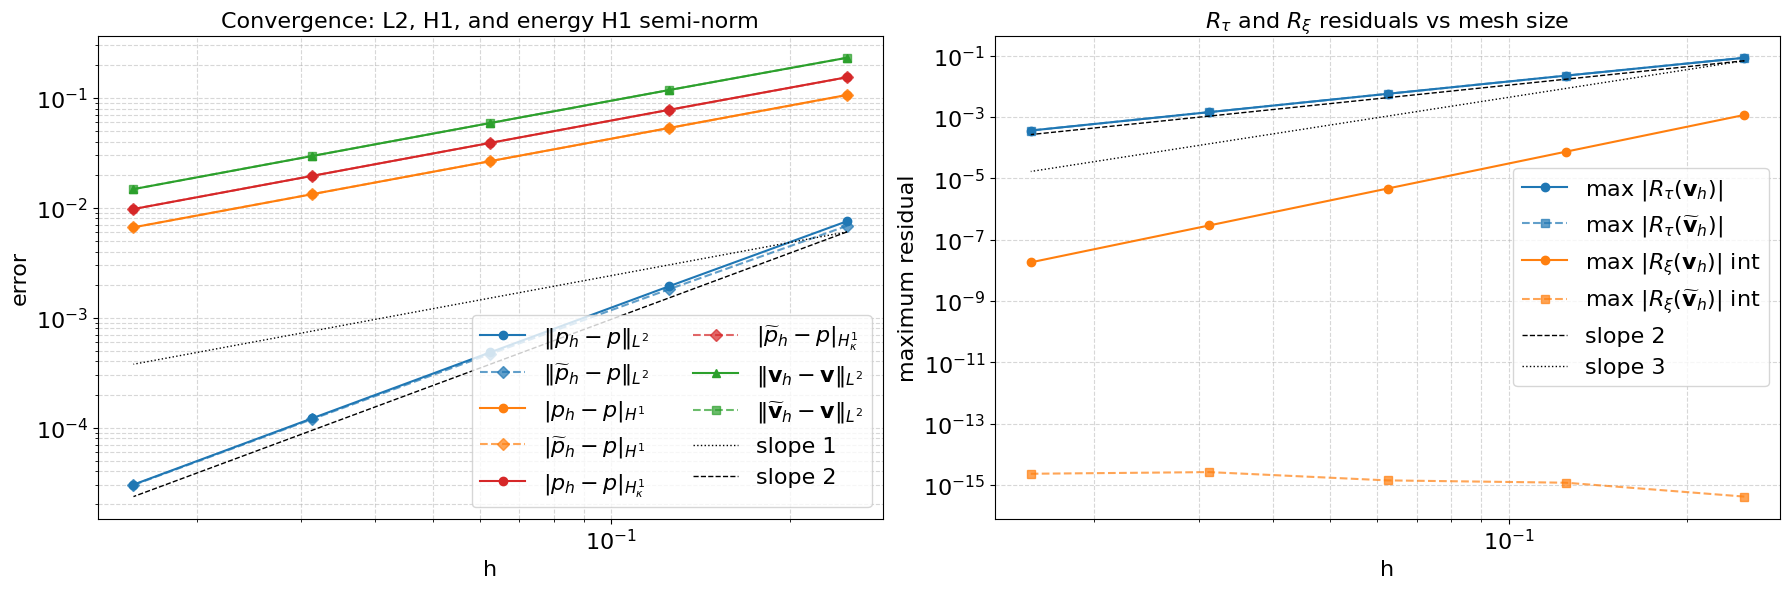

In [11]:
# ============================================================
# Convergence plots
# ============================================================
plot_font = 16
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

h_ref = np.array([hs[0], hs[-1]])

# -- Left: pressure errors (L2, std-H1, energy-H1) + flux L2 --
axes[0].loglog(hs, p_errs,    "o-",   color="C0",  label=r"$\|p_h-p\|_{L^2}$")
axes[0].loglog(hs, pREC_errs, "D--",  color="C0",  label=r"$\|\widetilde p_h-p\|_{L^2}$", alpha=0.7)
axes[0].loglog(hs, p_H1s,     "o-",   color="C1",  label=r"$|p_h-p|_{H^1}$")
axes[0].loglog(hs, pR_H1s,    "D--",  color="C1",  label=r"$|\widetilde p_h-p|_{H^1}$", alpha=0.7)
axes[0].loglog(hs, p_H1ks,    "o-",   color="C3",  label=r"$|p_h-p|_{H^1_\kappa}$")
axes[0].loglog(hs, pR_H1ks,   "D--",  color="C3",  label=r"$|\widetilde p_h-p|_{H^1_\kappa}$", alpha=0.7)
axes[0].loglog(hs, qCG_errs,  "^-",   color="C2",  label=r"$\|\mathbf{v}_h-\mathbf{v}\|_{L^2}$")
axes[0].loglog(hs, qR_errs,   "s--",  color="C2",  label=r"$\|\widetilde{\mathbf{v}}_h-\mathbf{v}\|_{L^2}$", alpha=0.7)
# reference slopes
axes[0].loglog(h_ref, 0.8 * p_errs[0] * (h_ref / hs[0]),    "k:",  linewidth=1, label="slope 1")
axes[0].loglog(h_ref, 0.8 * p_errs[0] * (h_ref / hs[0])**2, "k--", linewidth=1, label="slope 2")
axes[0].set_xlabel("h", fontsize=plot_font)
axes[0].set_ylabel("error", fontsize=plot_font)
axes[0].set_title("Convergence: L2, H1, and energy H1 semi-norm", fontsize=plot_font)
axes[0].tick_params(axis="both", labelsize=plot_font)
axes[0].legend(fontsize=plot_font, ncol=2)
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)

# -- Right: residuals vs mesh size --
# Whole-element curves are diagnostics.
# CV interior uses the physical source int_C f; Deng should be near machine precision.
axes[1].loglog(hs, [r["max_Ri_CG"]         for r in results], "o-",  color="C0", label=r"max $|R_\tau(\mathbf{v}_h)|$")
axes[1].loglog(hs, [r["max_Ri_rec"]        for r in results], "s--", color="C0", label=r"max $|R_\tau(\widetilde{\mathbf{v}}_h)|$", alpha=0.7)
axes[1].loglog(hs, [r["max_Ri_cv_int_cg"]  for r in results], "o-",  color="C1", label=r"max $|R_\xi(\mathbf{v}_h)|$ int")
axes[1].loglog(hs, [r["max_Ri_cv_int_rec"] for r in results], "s--", color="C1", label=r"max $|R_\xi(\widetilde{\mathbf{v}}_h)|$ int", alpha=0.7)
# reference slopes
axes[1].loglog(h_ref, 0.8 * ri_CG[0] * (h_ref / hs[0])**2, "k--", linewidth=1, label="slope 2")
axes[1].loglog(h_ref, 0.8 * ri_CG[0] * (h_ref / hs[0])**3, "k:",  linewidth=1, label="slope 3")
axes[1].set_xlabel("h", fontsize=plot_font)
axes[1].set_ylabel(r"maximum residual", fontsize=plot_font)
axes[1].set_title(r"$R_\tau$ and $R_\xi$ residuals vs mesh size", fontsize=plot_font)
axes[1].tick_params(axis="both", labelsize=plot_font)
axes[1].legend(fontsize=plot_font)
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Comparison memo  (paste PINN results here for side-by-side)
# ============================================================
# PINN notebook current output (ref=6, h=1/64):
#   DOFs in V              = 4225
#   CG solve time          = 1.665633 s
#   CG flux collect time   = 0.116327 s
#   q_rec PINN time        = 146.284924 s
#   Total hybrid time      = 148.066883 s
#   ||p_CG  - p_exact||_L2 = 3.030237e-05
#   ||q_CG  - q_exact||_L2 = 1.478365e-02
#   ||q_rec - q_exact||_L2 = 1.015955e-02   (PINN)
#   max  |R_i| CG          = 3.643568e-04
#   max  |R_i| q_rec       = 2.155540e-05   (PINN)
#   mean |R_i| CG          = 1.424278e-04
#   mean |R_i| q_rec       = 1.555451e-06
#
# Deng et al. values above are printed in cell-06 for REF_DEMO=6.
# Timing comparison:
#   Deng total = CG solve time + Deng post-processing time.
#   PINN total = CG solve time + flux collection time + PINN training time.
print("See cell-06 and the computation-time table above for Deng ref=6.")

See cell-06 and the computation-time table above for Deng ref=6.
